In [2]:
# pip install pandas numpy scikit-learn unidecode
import pandas as pd
import numpy as np
from unidecode import unidecode
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor
from pathlib import Path

# --------------------
# 0) LIST YOUR SEASONS HERE (season_label -> file path)
#    Use increasing order; labels can be strings like "2022/23"
SEASONS = {
    "2022/23": "epl_players_2022_23_fbref_like.csv",
    "2023/24": "epl_players_2023_24_fbref_like.csv",
    "2024/25": "epl_player_stats_24_25.csv",   # Kaggle-like
    # Add more when you have them, e.g.:
    # "2021/22": "epl_players_2021_22_fbref_like.csv",
}

# --------------------
# 1) Helpers

RENAME_CANON = {
    # common variants mapped to canonical names used in this pipeline
    "Player": "Player Name",
    "Team": "Club",
    "Squad": "Club",
    "Nation": "Nationality",
    "Pos": "Position",
    "MP": "Appearances",
    "Min": "Minutes",
    "Gls": "Goals",
    "Ast": "Assists",
    "Shots on Target": "Shots On Target",
    "Shots On Target": "Shots On Target",
    "Passes_Att": "Passes",          # FBref attempt column
    "Cmp": "Successful Passes",
    "Cmp%": "Passes%",
}

FEATS = [
    "G90","A90","GA90","Sh90","SoT90","Touches90","Carries90","PrgC90",
    "PassAtt90","TB90","SOT%","Passes%","Age"
]

def canon_name(x: str) -> str:
    if pd.isna(x): return ""
    x = unidecode(str(x)).lower().strip()
    x = " ".join(x.split())
    return x

def build_key(df, name_col="Player Name", born_col="Born"):
    key = df[name_col].map(canon_name)
    if born_col in df.columns:
        year = pd.to_numeric(df[born_col], errors="coerce").fillna(-1).astype(int).astype(str)
        key = key + "|" + year
    return key

def safe_div(num, den):
    num = pd.to_numeric(num, errors="coerce")
    den = pd.to_numeric(den, errors="coerce")
    with np.errstate(divide='ignore', invalid='ignore'):
        x = num / den
        x[~np.isfinite(x)] = np.nan
    return x

def load_and_normalize(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    # light rename pass
    rename_map = {k:v for k,v in RENAME_CANON.items() if k in df.columns}
    df = df.rename(columns=rename_map)
    # ensure core columns exist
    for c in ["Player Name","Club","Nationality","Position","Appearances","Minutes","Goals","Assists",
              "Shots","Shots On Target","Touches","Carries","Progressive Carries","Passes",
              "Through Balls","SOT%","Passes%","Age","Born"]:
        if c not in df.columns:
            df[c] = np.nan
    # strip whitespace
    for c in ["Player Name","Club","Nationality","Position"]:
        df[c] = df[c].astype(str).str.strip()
    return df

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    m = out["Minutes"].replace(0, np.nan)
    out["G90"]   = safe_div(out["Goals"], m) * 90
    out["A90"]   = safe_div(out["Assists"], m) * 90
    out["GA90"]  = out["G90"] + out["A90"]
    out["Sh90"]  = safe_div(out["Shots"], m) * 90
    out["SoT90"] = safe_div(out["Shots On Target"], m) * 90
    out["Touches90"] = safe_div(out["Touches"], m) * 90
    out["Carries90"] = safe_div(out["Carries"], m) * 90
    out["PrgC90"]    = safe_div(out["Progressive Carries"], m) * 90
    out["PassAtt90"] = safe_div(out["Passes"], m) * 90
    out["TB90"]      = safe_div(out["Through Balls"], m) * 90
    for c in ["SOT%","Passes%","Age"]:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def attach_key(df: pd.DataFrame) -> pd.DataFrame:
    # prefer name|born-year when available; fallback to name-only
    if "Born" in df.columns:
        df["player_key"] = build_key(df, "Player Name", "Born")
        if df["player_key"].str.endswith("|-1").all():
            df["player_key"] = df["Player Name"].map(canon_name)
    else:
        df["player_key"] = df["Player Name"].map(canon_name)
    return df

def make_pair_samples(prev_df, next_df):
    """
    Returns:
      data: rows = players in both seasons, cols = FEATS + 'target'
      prev_i, next_i: aligned slices with identifiers (for later pretty output)
    """
    keys = set(prev_df["player_key"]).intersection(set(next_df["player_key"]))
    prev_i = prev_df[prev_df["player_key"].isin(keys)].copy()
    next_i = next_df[next_df["player_key"].isin(keys)].copy()

    # Build target from next season: GA90_next
    m = next_i["Minutes"].replace(0, np.nan)
    next_i["G90_next"]  = safe_div(next_i["Goals"], m) * 90
    next_i["A90_next"]  = safe_div(next_i["Assists"], m) * 90
    next_i["GA90_next"] = next_i["G90_next"] + next_i["A90_next"]

    y = next_i[["player_key","GA90_next"]].rename(columns={"GA90_next":"target"})
    X = prev_i[["player_key"] + [c for c in FEATS if c in prev_i.columns]].copy()

    data = X.merge(y, on="player_key", how="inner").dropna(subset=["target"])
    return data, prev_i, next_i

# --------------------
# 2) Load all seasons
season_labels = list(SEASONS.keys())
assert season_labels == sorted(season_labels), "Please order SEASONS chronologically."

raw = {}
for s, path in SEASONS.items():
    if not Path(path).exists():
        raise FileNotFoundError(f"{s} file missing: {path}")
    df = load_and_normalize(path)
    df = attach_key(df)
    df = engineer_features(df)
    raw[s] = df

# --------------------
# 3) Build training pairs from every consecutive (t -> t+1) where next season has labels
pairs = []
aligned_prev = {}
aligned_next = {}

for i in range(len(season_labels)-1):
    s_prev, s_next = season_labels[i], season_labels[i+1]
    data, prev_i, next_i = make_pair_samples(raw[s_prev], raw[s_next])
    if not data.empty:
        data["pair"] = f"{s_prev}→{s_next}"
        pairs.append(data)
        aligned_prev[s_next] = prev_i   # prev side used to predict next
        aligned_next[s_next] = next_i   # next side with labels
        print(f"Pair ready: {s_prev} -> {s_next}  (samples={len(data)})")
    else:
        print(f"Skipped pair (no labeled overlap): {s_prev} -> {s_next}")

if not pairs:
    raise ValueError("No trainable season pairs found. Check column names and minutes/goals/assists in 'next' seasons.")

train_data = pd.concat(pairs, ignore_index=True)

# --------------------
# 4) Train HGBR on concatenated pairs
X = train_data.drop(columns=["player_key","target","pair"]).apply(pd.to_numeric, errors="coerce")
X = X.replace([np.inf, -np.inf], np.nan)
y = train_data["target"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42)
model = HistGradientBoostingRegressor(
    max_depth=4, learning_rate=0.07, max_iter=800,
    l2_regularization=1.0, early_stopping=True, validation_fraction=0.2,
    random_state=42
)


Pair ready: 2022/23 -> 2023/24  (samples=368)
Pair ready: 2023/24 -> 2024/25  (samples=348)


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
import os

RMSE: 0.2427
MAE: 0.1618
R²: 0.2975


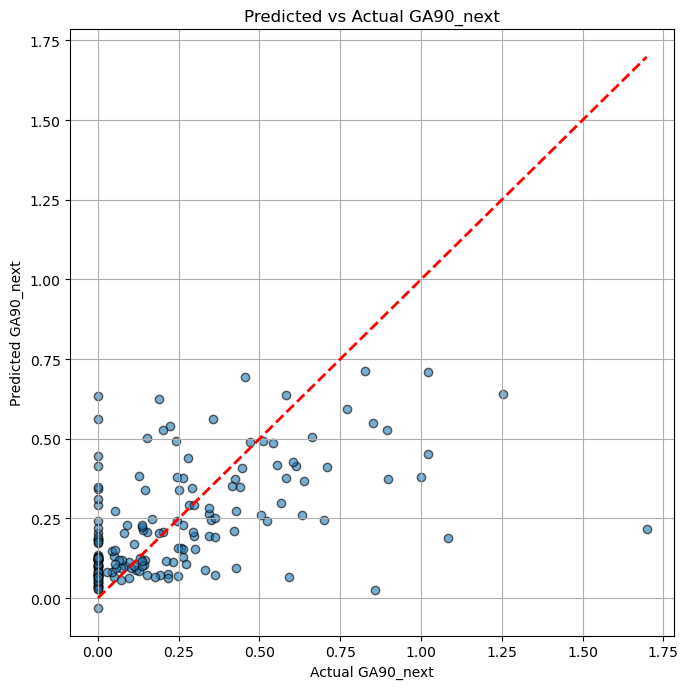

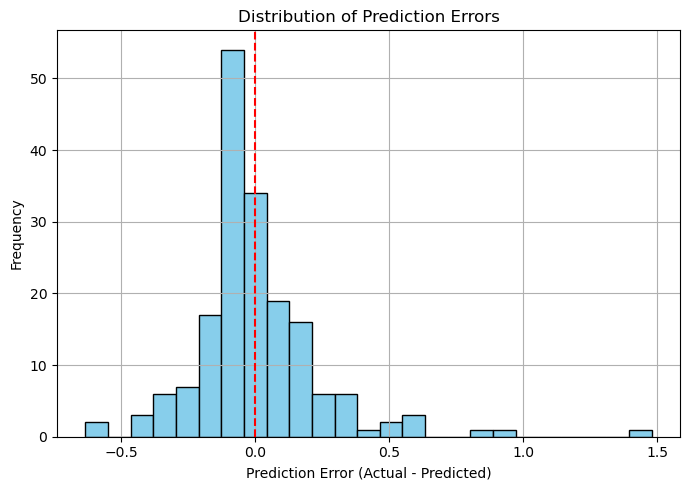


Computing permutation feature importance (this may take ~30 seconds)...


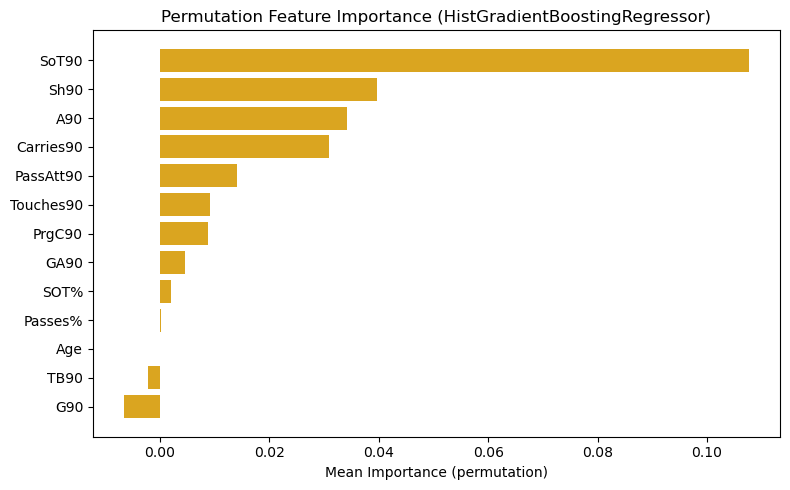

Validation — RMSE: 0.2427  R^2: 0.297
Saved: investable_players_pred_202426-26.csv
              player_key           Player Name                     Club  \
0        kevin de bruyne       Kevin De Bruyne          Manchester City   
1        nicolas jackson       Nicolas Jackson                  Chelsea   
2          harry maguire         Harry Maguire        Manchester United   
3         joshua zirkzee        Joshua Zirkzee        Manchester United   
4          lucas paqueta         Lucas Paquetá          West Ham United   
5   jorgen strand larsen  Jørgen Strand Larsen  Wolverhampton Wanderers   
6          ollie watkins         Ollie Watkins              Aston Villa   
7        bruno guimaraes       Bruno Guimarães         Newcastle United   
8          ethan pinnock         Ethan Pinnock                Brentford   
9           raul jimenez          Raúl Jiménez                   Fulham   
10        anthony gordon        Anthony Gordon         Newcastle United   
11      mateus fe

In [10]:

# --- Create output folder if not exists ---
os.makedirs("out/plots", exist_ok=True)

# --- Train and predict ---
model.fit(X_tr, y_tr)
pred_te = model.predict(X_te)

# --- Evaluate ---
rmse = mean_squared_error(y_te, pred_te, squared=False)
mae = mean_absolute_error(y_te, pred_te)
r2 = r2_score(y_te, pred_te)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

# --- 1. Predicted vs Actual plot ---
plt.figure(figsize=(7,7))
plt.scatter(y_te, pred_te, alpha=0.6, edgecolor='k')
plt.plot([min(y_te), max(y_te)], [min(y_te), max(y_te)], 'r--', lw=2)
plt.xlabel("Actual GA90_next")
plt.ylabel("Predicted GA90_next")
plt.title("Predicted vs Actual GA90_next")
plt.grid(True)
plt.tight_layout()
plt.savefig("out/plots/predicted_vs_actual.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 2. Error distribution plot ---
errors = y_te - pred_te
plt.figure(figsize=(7,5))
plt.hist(errors, bins=25, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.grid(True)
plt.tight_layout()
plt.savefig("out/plots/error_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 3. Permutation Feature Importance ---
print("\nComputing permutation feature importance (this may take ~30 seconds)...")
r = permutation_importance(model, X_te, y_te, n_repeats=10, random_state=42, n_jobs=-1)

importances = pd.DataFrame({
    "Feature": X_te.columns,
    "Importance": r.importances_mean
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
plt.barh(importances["Feature"], importances["Importance"], color="goldenrod")
plt.gca().invert_yaxis()
plt.title("Permutation Feature Importance (HistGradientBoostingRegressor)")
plt.xlabel("Mean Importance (permutation)")
plt.tight_layout()
plt.savefig("out/plots/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()




print(f"Validation — RMSE: {mean_squared_error(y_te, pred_te, squared=False):.4f}  R^2: {r2_score(y_te, pred_te):.3f}")

# --------------------
# 5) Predict the NEXT season (latest+1) using features from the latest season
latest = season_labels[-1]             # e.g., "2024/25"
predict_for = f"{latest.split('/')[0]}{int(latest.split('/')[1]) + 1}/" \
              f"{int(latest.split('/')[1]) + 1:02d}"  # purely cosmetic label like "2025/26"

# Use the prev side aligned to the latest NEXT (if it existed during training) OR raw[latest]
# If latest had a "next" with labels (e.g., 24/25->25/26 later), we'd have aligned_prev[latest_next].
# Right now we want to score 25/26 using 24/25 features:
prev_latest = raw[latest]  # features for the most recent season

X_latest = prev_latest[[c for c in FEATS if c in prev_latest.columns]].apply(pd.to_numeric, errors="coerce")
X_latest = X_latest.replace([np.inf, -np.inf], np.nan)
pred_latest = model.predict(X_latest)

scored = prev_latest[["player_key","Player Name","Club","Position","Minutes","Goals","Assists"]].copy()
scored["pred_GA90_next"] = pred_latest
scored["investable"] = True  # investable universe = players with data in latest season

# Sort best-to-worst predicted GA90 for next season
scored = scored.sort_values("pred_GA90_next", ascending=False).reset_index(drop=True)

out_name = f"investable_players_pred_{predict_for.replace('/','-')}.csv"
scored.to_csv(out_name, index=False)
print(f"Saved: {out_name}")
print(scored.head(20))